# Tugas Praktikum 1: Scraping & Eksplorasi Data (EDA)

**Nama:** Rayyan Muhtar Ali
**NRP:** 5054251051
**Mata Kuliah:** Penambangan Data

**Sumber data:** halaman *Top Anime* MyAnimeList (https://myanimelist.net/topanime.php), diambil dengan `requests` + `BeautifulSoup`.

Datanya berupa tabel peringkat anime. Satu halaman berisi 50 baris, dan saya ambil 40 halaman sehingga totalnya 2000 baris dengan 7 kolom mentah. Alasan memilih sumber ini: strukturnya tabel HTML biasa (tidak perlu JavaScript), dan kolomnya campuran angka dan kategori sehingga cocok untuk latihan EDA.

## 1. Scraping Dataset

Yang diambil dari tiap baris tabel: peringkat, judul, tipe dan jumlah episode, periode tayang, jumlah anggota, skor, serta URL halaman detailnya.

In [1]:
import re
import time

import requests
import truststore
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from bs4 import BeautifulSoup

truststore.inject_into_ssl()  # antivirus di laptop saya bikin SSL error, jadi pakai sertifikat bawaan Windows

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (8, 4.5)
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)

In [2]:
HEADERS = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 "
                  "(KHTML, like Gecko) Chrome/140.0.0.0 Safari/537.36"
}
URL = "https://myanimelist.net/topanime.php?limit={}"


def ambil_baris(html):
    """Ambil semua baris anime dari satu halaman peringkat."""
    sup = BeautifulSoup(html, "html.parser")
    hasil = []

    for tr in sup.select("tr.ranking-list"):
        tag_judul = tr.select_one("h3.anime_ranking_h3 a")
        info = tr.select_one("div.information").get_text("\n", strip=True).split("\n")
        info = [x.strip() for x in info if x.strip()]

        hasil.append({
            "peringkat": tr.select_one("td.rank span").get_text(strip=True),
            "judul": tag_judul.get_text(strip=True),
            "tipe_episode": info[0] if len(info) > 0 else None,
            "periode_tayang": info[1] if len(info) > 1 else None,
            "anggota": info[2] if len(info) > 2 else None,
            "skor": tr.select_one("td.score span").get_text(strip=True),
            "url": tag_judul["href"],
        })

    return hasil

In [3]:
data = []

for limit in range(0, 2000, 50):
    r = requests.get(URL.format(limit), headers=HEADERS, timeout=30)
    r.raise_for_status()
    data += ambil_baris(r.text)

    if limit % 250 == 0:
        print(f"halaman limit={limit:<5} total baris = {len(data)}")

    time.sleep(1.2)  # jeda supaya tidak membebani server

print("selesai, total baris:", len(data))

halaman limit=0     total baris = 50


halaman limit=250   total baris = 300


halaman limit=500   total baris = 550


halaman limit=750   total baris = 800


halaman limit=1000  total baris = 1050


halaman limit=1250  total baris = 1300


halaman limit=1500  total baris = 1550


halaman limit=1750  total baris = 1800


selesai, total baris: 2000


In [4]:
df_mentah = pd.DataFrame(data)
df_mentah.to_csv("data_mentah_anime.csv", index=False, encoding="utf-8")

print(df_mentah.shape)
df_mentah.head()

(2000, 7)


,peringkat,judul,tipe_episode,periode_tayang,anggota,skor,url
0,1,Sousou no Frieren,TV (28 eps),Sep 2023 - Mar 2024,"1,514,421 members",9.25,https://myanimelist.net/anime/52991/Sousou_no_...
1,2,Fullmetal Alchemist: Brotherhood,TV (64 eps),Apr 2009 - Jul 2010,"3,734,710 members",9.11,https://myanimelist.net/anime/5114/Fullmetal_A...
2,3,Re:Zero kara Hajimeru Isekai Seikatsu 4th Season,TV (19 eps),Apr 2026 - Sep 2026,"328,230 members",9.11,https://myanimelist.net/anime/61316/Re_Zero_ka...
3,4,Bleach: Sennen Kessen-hen - Kashin-tan,TV (10 eps),Jul 2026 - Oct 2026,"164,305 members",9.09,https://myanimelist.net/anime/60636/Bleach__Se...
4,5,Steel Ball Run: JoJo no Kimyou na Bouken,ONA (? eps),Mar 2026 -,"233,438 members",9.08,https://myanimelist.net/anime/61469/Steel_Ball...


Hasil mentah sudah disimpan ke `data_mentah_anime.csv`, jadi kalau notebook dijalankan ulang hanya untuk analisis, bagian scraping tidak perlu diulang.

## 2. Import dan Pemahaman Dataset

In [5]:
df_mentah = pd.read_csv("data_mentah_anime.csv")
df_mentah.head()

,peringkat,judul,tipe_episode,periode_tayang,anggota,skor,url
0,1,Sousou no Frieren,TV (28 eps),Sep 2023 - Mar 2024,"1,514,421 members",9.25,https://myanimelist.net/anime/52991/Sousou_no_...
1,2,Fullmetal Alchemist: Brotherhood,TV (64 eps),Apr 2009 - Jul 2010,"3,734,710 members",9.11,https://myanimelist.net/anime/5114/Fullmetal_A...
2,3,Re:Zero kara Hajimeru Isekai Seikatsu 4th Season,TV (19 eps),Apr 2026 - Sep 2026,"328,230 members",9.11,https://myanimelist.net/anime/61316/Re_Zero_ka...
3,4,Bleach: Sennen Kessen-hen - Kashin-tan,TV (10 eps),Jul 2026 - Oct 2026,"164,305 members",9.09,https://myanimelist.net/anime/60636/Bleach__Se...
4,5,Steel Ball Run: JoJo no Kimyou na Bouken,ONA (? eps),Mar 2026 -,"233,438 members",9.08,https://myanimelist.net/anime/61469/Steel_Ball...


In [6]:
print("Jumlah baris dan kolom:", df_mentah.shape)
print()
df_mentah.info()

Jumlah baris dan kolom: (2000, 7)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   peringkat       2000 non-null   int64  
 1   judul           2000 non-null   object 
 2   tipe_episode    2000 non-null   object 
 3   periode_tayang  2000 non-null   object 
 4   anggota         2000 non-null   object 
 5   skor            2000 non-null   float64
 6   url             2000 non-null   object 
dtypes: float64(1), int64(1), object(5)
memory usage: 109.5+ KB


In [7]:
df_mentah.dtypes

peringkat           int64
judul              object
tipe_episode       object
periode_tayang     object
anggota            object
skor              float64
url                object
dtype: object

Semua kolom masih bertipe `object` karena hasil scraping berupa teks. Beberapa kolom juga masih gabungan dua informasi, misalnya `tipe_episode` berisi `TV (28 eps)` dan `periode_tayang` berisi `Sep 2023 - Mar 2024`. Kolom seperti itu saya pecah dulu supaya bisa dihitung.

In [8]:
df = df_mentah.copy()

df["peringkat"] = df["peringkat"].astype(int)
df["skor"] = pd.to_numeric(df["skor"], errors="coerce")
df["jumlah_anggota"] = pd.to_numeric(
    df["anggota"].str.replace(r"[^0-9]", "", regex=True), errors="coerce"
)

# "TV (28 eps)" -> tipe = TV, jumlah_episode = 28
pecah = df["tipe_episode"].str.extract(r"^(?P<tipe>.+?)\s*\((?P<eps>[\d?]+) eps\)")
df["tipe"] = pecah["tipe"]
df["jumlah_episode"] = pd.to_numeric(pecah["eps"], errors="coerce")

# "Sep 2023 - Mar 2024" -> bulan dan tahun mulai, lalu tahun selesai
mulai = df["periode_tayang"].str.extract(r"^(?:(?P<bulan>[A-Z][a-z]{2})\s+)?(?P<tahun>\d{4})")
df["bulan_mulai"] = mulai["bulan"]
df["tahun_mulai"] = pd.to_numeric(mulai["tahun"], errors="coerce")

selesai = df["periode_tayang"].str.extract(r"-\s*(?:[A-Z][a-z]{2}\s+)?(?P<tahun>\d{4})\s*$")
df["tahun_selesai"] = pd.to_numeric(selesai["tahun"], errors="coerce")

df["status_tayang"] = np.where(df["tahun_selesai"].isna(), "Masih tayang", "Selesai")
df["dekade"] = df["tahun_mulai"] // 10 * 10

df = df[["peringkat", "judul", "tipe", "jumlah_episode", "skor", "jumlah_anggota",
         "bulan_mulai", "tahun_mulai", "tahun_selesai", "status_tayang", "dekade", "url"]]

df.head()

,peringkat,judul,tipe,jumlah_episode,skor,jumlah_anggota,bulan_mulai,tahun_mulai,tahun_selesai,status_tayang,dekade,url
0,1,Sousou no Frieren,TV,28.0,9.25,1514421,Sep,2023,2024.0,Selesai,2020,https://myanimelist.net/anime/52991/Sousou_no_...
1,2,Fullmetal Alchemist: Brotherhood,TV,64.0,9.11,3734710,Apr,2009,2010.0,Selesai,2000,https://myanimelist.net/anime/5114/Fullmetal_A...
2,3,Re:Zero kara Hajimeru Isekai Seikatsu 4th Season,TV,19.0,9.11,328230,Apr,2026,2026.0,Selesai,2020,https://myanimelist.net/anime/61316/Re_Zero_ka...
3,4,Bleach: Sennen Kessen-hen - Kashin-tan,TV,10.0,9.09,164305,Jul,2026,2026.0,Selesai,2020,https://myanimelist.net/anime/60636/Bleach__Se...
4,5,Steel Ball Run: JoJo no Kimyou na Bouken,ONA,NaN,9.08,233438,Mar,2026,NaN,Masih tayang,2020,https://myanimelist.net/anime/61469/Steel_Ball...


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   peringkat       2000 non-null   int64  
 1   judul           2000 non-null   object 
 2   tipe            2000 non-null   object 
 3   jumlah_episode  1986 non-null   float64
 4   skor            2000 non-null   float64
 5   jumlah_anggota  2000 non-null   int64  
 6   bulan_mulai     1998 non-null   object 
 7   tahun_mulai     2000 non-null   int64  
 8   tahun_selesai   1976 non-null   float64
 9   status_tayang   2000 non-null   object 
 10  dekade          2000 non-null   int64  
 11  url             2000 non-null   object 
dtypes: float64(3), int64(4), object(5)
memory usage: 187.6+ KB


### Identifikasi tipe atribut

| Kolom | Tipe atribut | Alasan |
|---|---|---|
| `peringkat` | Ordinal | angka urutan; selisih satu peringkat tidak bermakna sama di semua posisi |
| `judul` | Nominal (identitas) | nama, tidak bisa diurutkan |
| `tipe` | Nominal | kategori TV / Movie / ONA / OVA / Special / TV Special |
| `jumlah_episode` | Numerik diskrit | cacahan episode |
| `skor` | Numerik kontinu | rata-rata rating pengguna, ada angka di belakang koma |
| `jumlah_anggota` | Numerik diskrit | cacahan pengguna yang memasukkan anime ke list |
| `bulan_mulai` | Nominal (siklis) | nama bulan, urutannya berulang tiap tahun |
| `tahun_mulai` | Numerik diskrit (skala interval) | tahun mulai tayang |
| `tahun_selesai` | Numerik diskrit (skala interval) | tahun selesai tayang |
| `status_tayang` | Nominal biner | selesai atau masih tayang |
| `dekade` | Ordinal | hasil pengelompokan tahun, punya urutan |
| `url` | Nominal (identitas) | alamat halaman detail |

## 3. Analisis Statistik dan Kualitas Data

In [10]:
kolom_numerik = ["skor", "jumlah_episode", "jumlah_anggota", "tahun_mulai", "peringkat"]

ringkasan = pd.DataFrame({
    "rata_rata": df[kolom_numerik].mean(),
    "median": df[kolom_numerik].median(),
    "modus": df[kolom_numerik].mode().iloc[0],
    "std": df[kolom_numerik].std(),
    "min": df[kolom_numerik].min(),
    "maks": df[kolom_numerik].max(),
}).round(2)

ringkasan

,rata_rata,median,modus,std,min,maks
skor,7.96,7.87,7.58,0.34,7.55,9.25
jumlah_episode,17.95,12.00,1.00,53.05,1.00,1787.00
jumlah_anggota,323486.14,124991.50,1143.00,510697.39,864.00,4425476.00
tahun_mulai,2014.13,2016.00,2023.00,9.89,1970.00,2026.00
peringkat,1000.50,1000.50,1.00,577.49,1.00,2000.00


In [11]:
df[kolom_numerik].describe().round(2)

,skor,jumlah_episode,jumlah_anggota,tahun_mulai,peringkat
count,2000.00,1986.00,2000.00,2000.00,2000.00
mean,7.96,17.95,323486.14,2014.13,1000.50
std,0.34,53.05,510697.39,9.89,577.49
min,7.55,1.00,864.00,1970.00,1.00
25%,7.69,1.00,42644.25,2009.00,500.75
50%,7.87,12.00,124991.50,2016.00,1000.50
75%,8.17,19.75,358451.50,2022.00,1500.25
max,9.25,1787.00,4425476.00,2026.00,2000.00


Yang langsung terlihat: `skor` sebarannya sempit, jarak nilai terendah ke tertinggi hanya sekitar dua poin. Sebaliknya `jumlah_anggota` dan `jumlah_episode` rentangnya sangat lebar dan rata-ratanya jauh di atas median, tanda distribusinya menceng ke kanan.

In [12]:
for kol in ["tipe", "status_tayang", "dekade"]:
    tabel = pd.DataFrame({
        "frekuensi": df[kol].value_counts(dropna=False),
        "persen": (df[kol].value_counts(dropna=False, normalize=True) * 100).round(2),
    })
    print(f"--- {kol} ---")
    print(tabel)
    print()

--- tipe ---
            frekuensi  persen
tipe                         
TV               1031   51.55
Movie             451   22.55
ONA               219   10.95
OVA               167    8.35
Special            81    4.05
TV Special         51    2.55

--- status_tayang ---
               frekuensi  persen
status_tayang                   
Selesai             1976    98.8
Masih tayang          24     1.2

--- dekade ---
        frekuensi  persen
dekade                   
2010          756   37.80
2020          716   35.80
2000          353   17.65
1990          112    5.60
1980           45    2.25
1970           18    0.90



In [13]:
print("Sepuluh bulan mulai tayang terbanyak")
df["bulan_mulai"].value_counts().head(10)

Sepuluh bulan mulai tayang terbanyak


bulan_mulai
Apr    405
Oct    375
Jul    293
Jan    258
Dec    108
Mar    106
Sep     95
Aug     93
Feb     79
Jun     67
Name: count, dtype: int64

### Nilai yang hilang

In [14]:
hilang = pd.DataFrame({
    "jumlah_hilang": df.isna().sum(),
    "persen": (df.isna().mean() * 100).round(2),
})

hilang

,jumlah_hilang,persen
peringkat,0,0.0
judul,0,0.0
tipe,0,0.0
jumlah_episode,14,0.7
skor,0,0.0
jumlah_anggota,0,0.0
bulan_mulai,2,0.1
tahun_mulai,0,0.0
tahun_selesai,24,1.2
status_tayang,0,0.0


In [15]:
df[df["jumlah_episode"].isna()].head()

,peringkat,judul,tipe,jumlah_episode,skor,jumlah_anggota,bulan_mulai,tahun_mulai,tahun_selesai,status_tayang,dekade,url
4,5,Steel Ball Run: JoJo no Kimyou na Bouken,ONA,NaN,9.08,233438,Mar,2026,NaN,Masih tayang,2020,https://myanimelist.net/anime/61469/Steel_Ball...
55,56,One Piece,TV,NaN,8.73,2726660,Oct,1999,NaN,Masih tayang,1990,https://myanimelist.net/anime/21/One_Piece
98,99,Chiikawa,TV,NaN,8.62,25635,Apr,2022,NaN,Masih tayang,2020,https://myanimelist.net/anime/50250/Chiikawa
183,184,Tian Guan Cifu Short Films,ONA,NaN,8.47,12486,Feb,2025,NaN,Masih tayang,2020,https://myanimelist.net/anime/60988/Tian_Guan_...
321,322,Mushen Ji,ONA,NaN,8.31,16399,Oct,2024,NaN,Masih tayang,2020,https://myanimelist.net/anime/59953/Mushen_Ji


In [16]:
df[df["bulan_mulai"].isna()][["judul", "tipe", "tahun_mulai", "tahun_selesai", "status_tayang"]]

,judul,tipe,tahun_mulai,tahun_selesai,status_tayang
1466,Saint Seiya: Meiou Hades Juuni Kyuu-hen - Yomi...,Special,2003,2003.0,Selesai
1681,Meitantei Conan Movie 10: Tantei-tachi no Requ...,TV Special,2006,2006.0,Selesai


Nilai hilangnya sedikit dan penyebabnya jelas, bukan karena kesalahan scraping:

- `jumlah_episode` kosong untuk anime yang masih tayang; di situs aslinya memang ditulis `? eps`.
- `tahun_selesai` kosong untuk anime yang belum tamat, formatnya `Apr 2026 -` tanpa tanggal akhir.
- `bulan_mulai` kosong untuk beberapa judul lama yang di MyAnimeList hanya dicatat tahunnya.

Karena jumlahnya di bawah 2% dan nilainya memang belum ada (bukan hilang secara acak), saya tidak mengisinya dengan rata-rata atau median. Menambal `jumlah_episode` anime yang masih tayang justru membuat datanya salah. Barisnya tetap dipakai dan hanya diabaikan pada grafik yang membutuhkan kolom tersebut. Kolom `status_tayang` yang saya buat sekaligus menjadi penanda baris mana yang datanya belum lengkap.

### Deteksi outlier

Saya pakai metode IQR: nilai di luar rentang Q1 - 1,5 x IQR sampai Q3 + 1,5 x IQR dihitung sebagai outlier.

In [17]:
def batas_iqr(s):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


baris = []
for kol in ["skor", "jumlah_episode", "jumlah_anggota"]:
    nilai = df[kol].dropna()
    bawah, atas = batas_iqr(nilai)
    n = int(((nilai < bawah) | (nilai > atas)).sum())
    baris.append({
        "kolom": kol,
        "batas_bawah": round(bawah, 2),
        "batas_atas": round(atas, 2),
        "jumlah_outlier": n,
        "persen": round(n / len(nilai) * 100, 2),
    })

pd.DataFrame(baris)

,kolom,batas_bawah,batas_atas,jumlah_outlier,persen
0,skor,6.97,8.89,27,1.35
1,jumlah_episode,-27.12,47.88,142,7.15
2,jumlah_anggota,-431066.62,832162.38,221,11.05


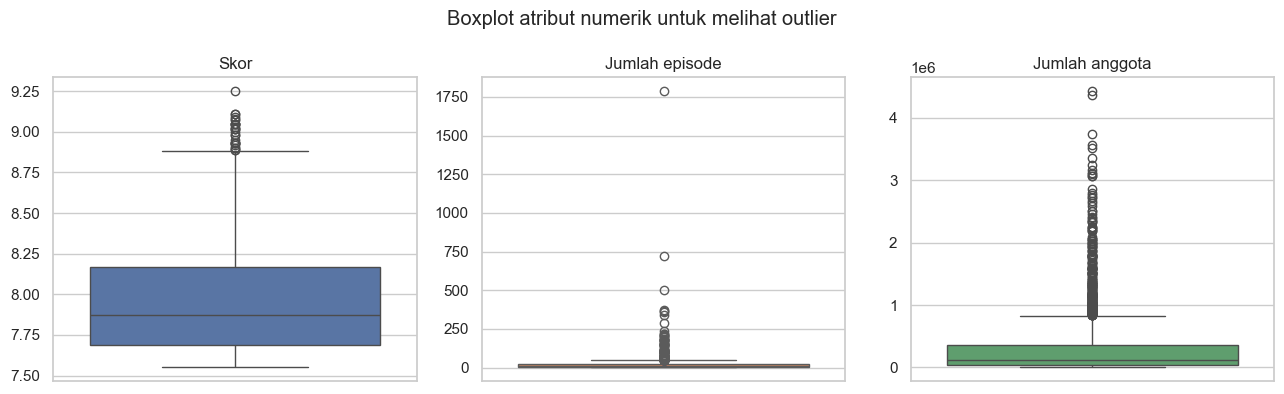

In [18]:
fig, ax = plt.subplots(1, 3, figsize=(13, 4))

sns.boxplot(y=df["skor"], ax=ax[0], color="#4c72b0")
ax[0].set_title("Skor")

sns.boxplot(y=df["jumlah_episode"], ax=ax[1], color="#dd8452")
ax[1].set_title("Jumlah episode")

sns.boxplot(y=df["jumlah_anggota"], ax=ax[2], color="#55a868")
ax[2].set_title("Jumlah anggota")

for a in ax:
    a.set_ylabel("")

fig.suptitle("Boxplot atribut numerik untuk melihat outlier")
plt.tight_layout()
plt.show()

In [19]:
print("Episode terbanyak")
print(df.nlargest(5, "jumlah_episode")[["judul", "tipe", "jumlah_episode", "skor"]].to_string(index=False))
print()
print("Anggota terbanyak")
print(df.nlargest(5, "jumlah_anggota")[["judul", "tipe", "jumlah_anggota", "skor"]].to_string(index=False))

Episode terbanyak
                                           judul tipe  jumlah_episode  skor
                                 Doraemon (1979)   TV          1787.0  7.90
                                   Wushen Zhuzai  ONA           720.0  7.59
                              Naruto: Shippuuden   TV           500.0  8.29
Kochira Katsushikaku Kameari Kouenmae Hashutsujo   TV           373.0  7.82
                                          Bleach   TV           366.0  8.00

Anggota terbanyak
                           judul tipe  jumlah_anggota  skor
              Shingeki no Kyojin   TV         4425476  8.58
                      Death Note   TV         4363546  8.62
Fullmetal Alchemist: Brotherhood   TV         3734710  9.11
                   One Punch Man   TV         3558606  8.47
                Kimetsu no Yaiba   TV         3507154  8.39


Outlier di sini nilainya wajar, bukan kesalahan input. Anime dengan ratusan episode memang ada, yaitu serial panjang yang tayang bertahun-tahun. Judul populer seperti yang muncul di daftar anggota terbanyak juga memang ditonton jutaan orang, sementara median dataset ini hanya di kisaran ratusan ribu. Skor yang terdeteksi outlier ikut masuk akal karena isi dataset ini 2000 anime peringkat teratas, jadi skornya menumpuk di rentang sempit dan sedikit judul di ujung atas langsung terhitung ekstrem.

Karena itu outliernya saya biarkan, tidak dibuang maupun dipotong. Penyesuaian yang saya lakukan hanya memakai skala logaritmik ketika menggambar `jumlah_anggota`, supaya bentuk distribusinya tetap terbaca dan tidak tertarik oleh segelintir judul populer.

## 4. Visualisasi Data

### 4.1 Distribusi skor

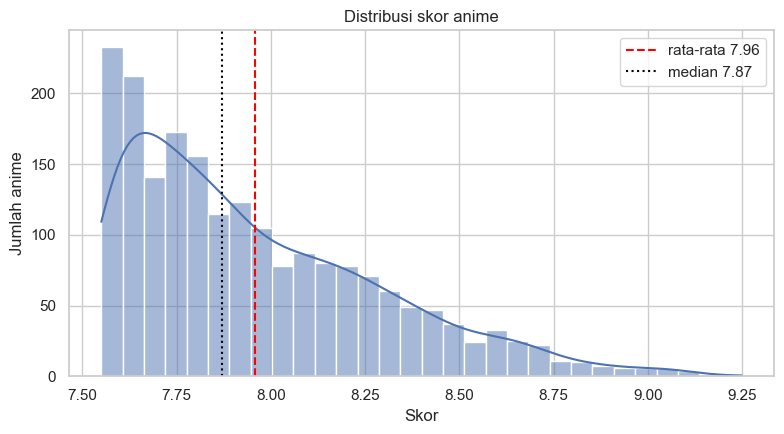

In [20]:
fig, ax = plt.subplots()
sns.histplot(df["skor"], bins=30, kde=True, color="#4c72b0", ax=ax)
ax.axvline(df["skor"].mean(), color="red", linestyle="--", label=f"rata-rata {df['skor'].mean():.2f}")
ax.axvline(df["skor"].median(), color="black", linestyle=":", label=f"median {df['skor'].median():.2f}")
ax.set_title("Distribusi skor anime")
ax.set_xlabel("Skor")
ax.set_ylabel("Jumlah anime")
ax.legend()
plt.tight_layout()
plt.show()

Skor menumpuk di sekitar 7,6 sampai 7,9 dan bentuknya menceng ke kanan: makin tinggi skornya, makin sedikit judulnya. Rata-rata (7,96) sedikit di atas median (7,87), jadi ekor atas menarik rata-rata tapi tidak jauh. Perlu diingat ini bukan distribusi skor seluruh anime, melainkan hanya 2000 peringkat teratas, sehingga batas bawahnya memang terpotong di angka 7,55.

### 4.2 Distribusi jumlah anggota

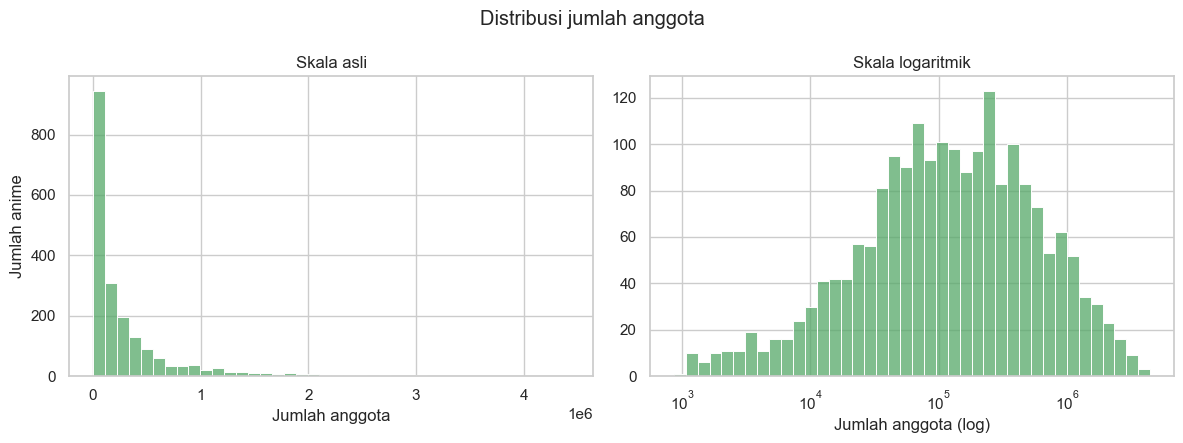

In [21]:
fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

sns.histplot(df["jumlah_anggota"], bins=40, color="#55a868", ax=ax[0])
ax[0].set_title("Skala asli")
ax[0].set_xlabel("Jumlah anggota")
ax[0].set_ylabel("Jumlah anime")

sns.histplot(df["jumlah_anggota"], bins=40, log_scale=True, color="#55a868", ax=ax[1])
ax[1].set_title("Skala logaritmik")
ax[1].set_xlabel("Jumlah anggota (log)")
ax[1].set_ylabel("")

fig.suptitle("Distribusi jumlah anggota")
plt.tight_layout()
plt.show()

Pada skala asli hampir semua batang menumpuk di kiri karena ada beberapa judul dengan jutaan anggota. Setelah dipindah ke skala logaritmik bentuknya jadi mendekati simetris, artinya popularitas anime sebarannya log-normal: banyak judul dengan puluhan sampai ratusan ribu anggota, dan hanya sedikit yang benar-benar masif.

### 4.3 Jumlah anime per tipe

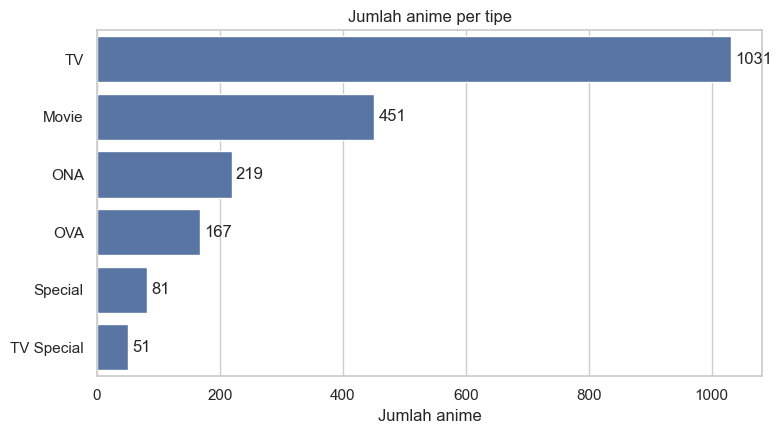

In [22]:
urutan = df["tipe"].value_counts().index

fig, ax = plt.subplots()
sns.countplot(data=df, y="tipe", order=urutan, color="#4c72b0", ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Jumlah anime per tipe")
ax.set_xlabel("Jumlah anime")
ax.set_ylabel("")
plt.tight_layout()
plt.show()

Tipe TV mendominasi, disusul Movie. ONA, OVA, Special, dan TV Special jumlahnya jauh lebih sedikit. Artinya di peringkat teratas MyAnimeList format serial TV dan film layar lebar yang paling banyak masuk, sedangkan format pendek seperti Special jarang menembus 2000 besar.

### 4.4 Jumlah anime per dekade

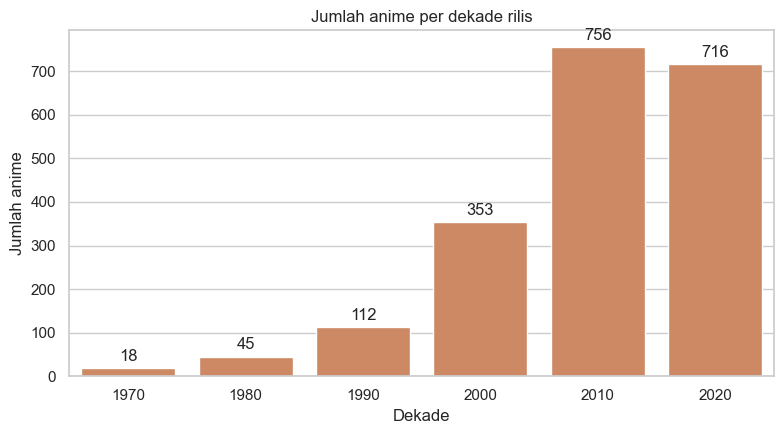

In [23]:
per_dekade = df["dekade"].value_counts().sort_index()

fig, ax = plt.subplots()
sns.barplot(x=per_dekade.index.astype(int).astype(str), y=per_dekade.values, color="#dd8452", ax=ax)
ax.bar_label(ax.containers[0], padding=3)
ax.set_title("Jumlah anime per dekade rilis")
ax.set_xlabel("Dekade")
ax.set_ylabel("Jumlah anime")
plt.tight_layout()
plt.show()

Sebagian besar judul berasal dari dekade 2010-an (756 judul), disusul 2020-an (716) yang angkanya sudah hampir menyamai padahal dekadenya belum genap sepuluh tahun. Anime sebelum 1990-an sangat sedikit, totalnya cuma 63 judul. Jadi dataset ini condong ke produksi modern, dan itu masuk akal karena penilaian di MyAnimeList berasal dari pengguna aktif yang kebanyakan menonton anime baru.

### 4.5 Hubungan skor dan jumlah anggota

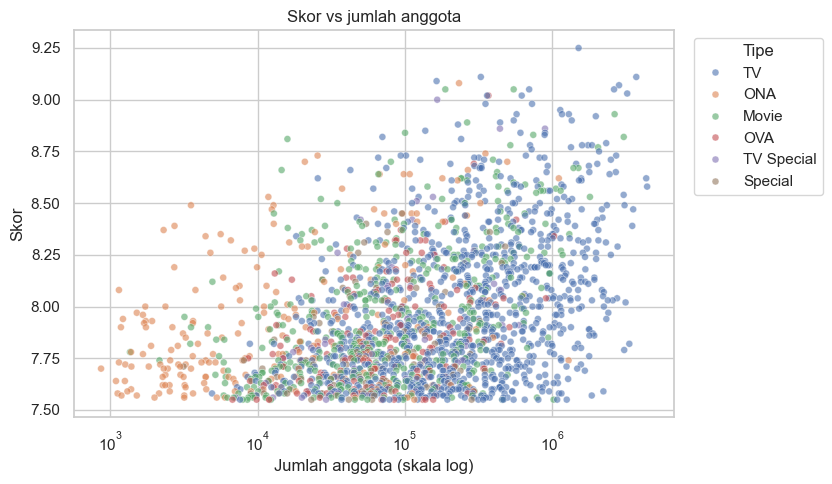

Korelasi Pearson skor vs log10(anggota): 0.39


In [24]:
fig, ax = plt.subplots(figsize=(8.5, 5))
sns.scatterplot(data=df, x="jumlah_anggota", y="skor", hue="tipe", alpha=0.6, s=25, ax=ax)
ax.set_xscale("log")
ax.set_title("Skor vs jumlah anggota")
ax.set_xlabel("Jumlah anggota (skala log)")
ax.set_ylabel("Skor")
ax.legend(title="Tipe", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

print("Korelasi Pearson skor vs log10(anggota):",
      round(df["skor"].corr(np.log10(df["jumlah_anggota"])), 3))

Ada kecenderungan naik, tapi tidak kuat. Korelasi skor dengan log jumlah anggota hanya 0,39, dan titiknya menyebar lebar. Jadi anime populer memang cenderung berskor lebih tinggi, namun popularitas bukan penentu skor. Terlihat juga cukup banyak judul dengan anggota sedikit tapi skornya tinggi, biasanya judul niche yang penontonnya terbatas. Titik bertipe Movie cenderung berkumpul di sisi kiri: median anggotanya sekitar 72 ribu, jauh di bawah tipe TV yang sekitar 260 ribu.

### 4.6 Korelasi antar atribut numerik

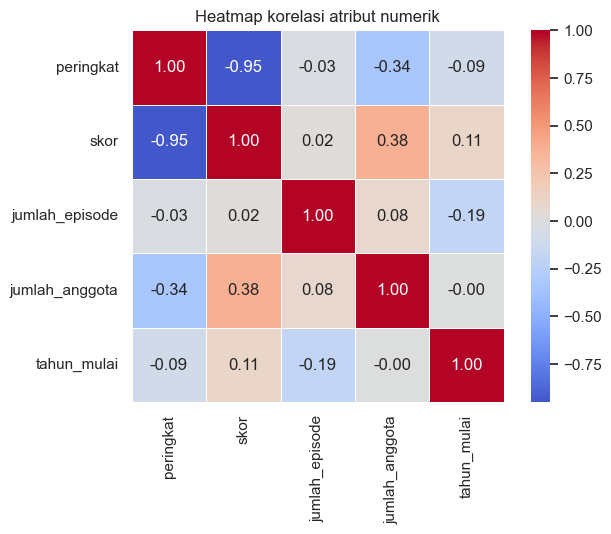

In [25]:
korelasi = df[["peringkat", "skor", "jumlah_episode", "jumlah_anggota", "tahun_mulai"]].corr()

fig, ax = plt.subplots(figsize=(7, 5.5))
sns.heatmap(korelasi, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True,
            linewidths=0.5, ax=ax)
ax.set_title("Heatmap korelasi atribut numerik")
plt.tight_layout()
plt.show()

`peringkat` dan `skor` korelasinya -0,95. Itu wajar karena peringkat di MyAnimeList memang disusun dari skor, jadi dua kolom ini praktis memuat informasi yang sama dan tidak perlu dipakai bersamaan kalau nanti dibuat model. Korelasi lainnya kecil: jumlah episode dengan skor hanya 0,02 dan tahun rilis dengan skor 0,11, artinya anime panjang atau anime baru tidak otomatis berskor lebih tinggi. Yang paling menonjol tetap hubungan positif antara skor dan jumlah anggota (0,38).

### 4.7 Sebaran skor per tipe

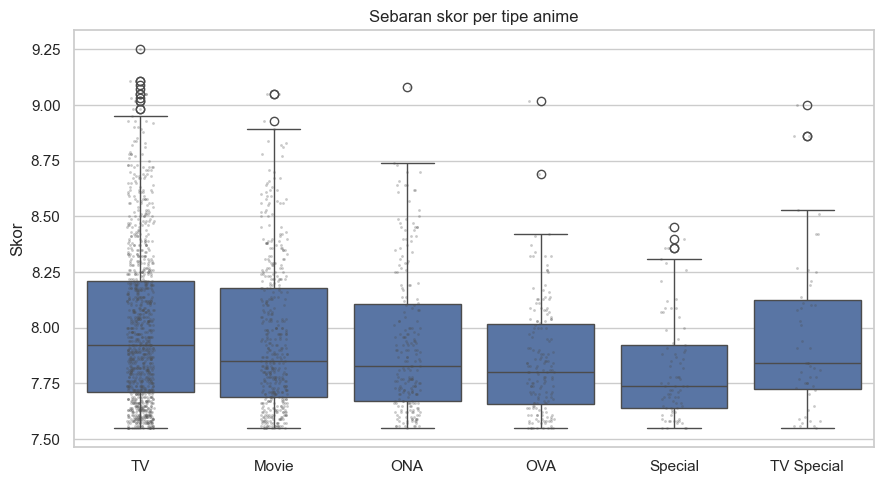

,count,mean,median,std
tipe,,,,
TV,1031,8.00,7.92,0.35
Movie,451,7.95,7.85,0.33
TV Special,51,7.96,7.84,0.36
ONA,219,7.93,7.83,0.32
OVA,167,7.85,7.80,0.25
Special,81,7.82,7.74,0.23


In [26]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.boxplot(data=df, x="tipe", y="skor", order=urutan, ax=ax)
sns.stripplot(data=df, x="tipe", y="skor", order=urutan, size=2, color=".3", alpha=0.3, ax=ax)
ax.set_title("Sebaran skor per tipe anime")
ax.set_xlabel("")
ax.set_ylabel("Skor")
plt.tight_layout()
plt.show()

df.groupby("tipe")["skor"].agg(["count", "mean", "median", "std"]).round(2).sort_values("median", ascending=False)

Median skor semua tipe berdekatan, rentangnya cuma 7,74 (Special) sampai 7,92 (TV), jadi tipe anime bukan pembeda skor yang kuat. Tipe TV dan Movie punya ekor atas yang lebih panjang karena jumlah judulnya paling banyak, sedangkan OVA dan Special sebarannya paling rapat (standar deviasi 0,25 dan 0,23). Kotak yang pendek di semua tipe sekali lagi menunjukkan skor dataset ini memang berkumpul di rentang sempit.

In [27]:
df.to_csv("data_bersih_anime.csv", index=False, encoding="utf-8")
print("data bersih disimpan:", df.shape)

data bersih disimpan: (2000, 12)


## 5. Laporan Analisis

### Deskripsi Dataset

Dataset diambil dengan scraping halaman *Top Anime* MyAnimeList pada 40 halaman peringkat, menghasilkan **2000 baris dan 7 kolom mentah**. Setelah kolom gabungan dipecah, dataset menjadi **12 kolom**, sehingga ketentuan minimal 5 fitur dan 1500 baris terpenuhi.

Isi kolomnya campuran beberapa tipe atribut: nominal (`judul`, `tipe`, `bulan_mulai`, `status_tayang`, `url`), ordinal (`peringkat`, `dekade`), numerik diskrit (`jumlah_episode`, `jumlah_anggota`, `tahun_mulai`, `tahun_selesai`), dan numerik kontinu (`skor`). Rentang tahunnya 1970 sampai 2026, dan tipe anime terbagi jadi enam kategori dengan TV paling banyak (1031 judul atau 51,6%), disusul Movie (451), ONA (219), OVA (167), Special (81), dan TV Special (51). Sebanyak 1976 judul berstatus selesai tayang dan 24 judul masih tayang.

### Statistik Deskriptif

| Atribut | Rata-rata | Median | Modus | Std | Min | Maks |
|---|---|---|---|---|---|---|
| skor | 7,96 | 7,87 | 7,58 | 0,34 | 7,55 | 9,25 |
| jumlah_episode | 17,95 | 12 | 1 | 53,05 | 1 | 1787 |
| jumlah_anggota | 323.486 | 124.992 | 1.143 | 510.697 | 864 | 4.425.476 |
| tahun_mulai | 2014 | 2016 | 2023 | 9,89 | 1970 | 2026 |

Pola yang terlihat dari tabel ini: `skor` sebarannya sangat sempit karena dataset hanya berisi peringkat teratas, sedangkan `jumlah_episode` dan `jumlah_anggota` rata-ratanya jauh di atas median, yang berarti distribusinya menceng ke kanan dan ditarik oleh sedikit nilai besar. Standar deviasi `jumlah_anggota` bahkan lebih besar dari rata-ratanya.

Untuk atribut kategorikal, `tipe` didominasi TV (51,6%) dan Movie (22,6%). Dari `bulan_mulai`, April (405) dan Oktober (375) paling sering muncul, yang cocok dengan kebiasaan industri anime merilis serial pada awal musim semi dan musim gugur.

### Penanganan Data

Nilai hilang hanya ada di tiga kolom dan semuanya di bawah 2%: `tahun_selesai` 24 baris (1,2%), `jumlah_episode` 14 baris (0,7%), dan `bulan_mulai` 2 baris (0,1%). Setelah dicek satu per satu, penyebabnya bukan kesalahan scraping melainkan memang belum ada nilainya: anime yang masih tayang ditulis `? eps` tanpa tanggal akhir, dan beberapa judul lama di MyAnimeList hanya dicatat tahunnya. Karena itu nilainya tidak saya isi dengan rata-rata atau median, sebab menambal jumlah episode anime yang belum tamat justru memalsukan data. Barisnya tetap dipertahankan dan hanya dilewati pada perhitungan yang butuh kolom tersebut, sementara kolom `status_tayang` yang saya buat sekaligus menandai baris mana yang belum lengkap.

Outlier dideteksi dengan metode IQR. Hasilnya `jumlah_anggota` 221 outlier (11,05%), `jumlah_episode` 142 outlier (7,15%), dan `skor` 27 outlier (1,35%). Nilai-nilai itu valid, bukan kesalahan input: Doraemon (1979) memang punya 1787 episode, dan *Shingeki no Kyojin* memang dimasukkan ke list oleh 4,4 juta pengguna. Outlier `skor` juga muncul justru karena datanya terlalu seragam, sehingga sedikit judul di ujung atas langsung melewati batas IQR. Jadi outlier tidak dibuang maupun dipotong. Penyesuaian yang dilakukan hanya pada visualisasi, yaitu memakai skala logaritmik untuk `jumlah_anggota` supaya bentuk distribusinya tetap terbaca.

### Visualisasi dan Interpretasi

Tujuh grafik dibuat pada bagian 4. Ringkasan temuannya:

1. **Histogram skor** menunjukkan sebaran menceng kanan yang terpusat di 7,6-7,9 dengan rentang sangat sempit, akibat dataset hanya memuat peringkat teratas.
2. **Histogram jumlah anggota** pada skala asli menumpuk di kiri, tetapi berubah mendekati simetris pada skala logaritmik. Popularitas anime mengikuti pola log-normal.
3. **Bar chart tipe** memperlihatkan dominasi format TV dan Movie, sedangkan format pendek seperti Special jarang masuk 2000 besar.
4. **Bar chart per dekade** menunjukkan dataset condong ke produksi 2010-an dan 2020-an.
5. **Scatter plot skor vs jumlah anggota** memberi korelasi 0,39 pada skala log, jadi hubungannya positif tapi lemah sampai sedang, dan ada banyak judul niche berskor tinggi dengan anggota sedikit.
6. **Heatmap korelasi** menegaskan `peringkat` dan `skor` hampir sepenuhnya redundan (-0,95), sementara jumlah episode dan tahun rilis hampir tidak berhubungan dengan skor.
7. **Boxplot skor per tipe** menunjukkan median antar tipe hanya berbeda tipis, sehingga tipe anime bukan pembeda kualitas yang berarti.

### Kesimpulan

Dataset hasil scraping ini bersih, hampir tidak punya nilai hilang, dan outliernya nyata sehingga tidak perlu dibuang. Temuan utamanya, skor pada peringkat teratas MyAnimeList sangat seragam dan tidak banyak dipengaruhi tipe, panjang episode, maupun tahun rilis. Faktor yang paling berkaitan dengan skor adalah popularitas, itu pun hanya pada tingkat lemah sampai sedang. Kalau nanti dataset ini dipakai untuk pemodelan, `peringkat` sebaiknya dibuang karena redundan dengan `skor`, dan `jumlah_anggota` sebaiknya ditransformasi logaritmik dulu agar sebarannya tidak terlalu menceng.